## Instabilité d'un jet de Bickley dans le modèle QG barotrope
Equations : 
$$
\begin{align}
&q = \left(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}\right) \psi +\beta y \\
&\frac{\partial q}{\partial t} + \mathrm{J}\left( \psi, q\right) = 0
\end{align}
$$

Ici, $x\in [0, 2\pi]$ et $y\in[-1, 1]$. Le champ de vitesse initial est de la forme :
$$
U(x, y) = U_0 \mathrm{sech}^2{\frac{y}{\alpha}} = U_0\frac{1}{\cosh^2{\frac{y}{\alpha}} }
$$
Ici, on prends $\alpha = 0.2$ et $U_0 = 2.0$. Les CLs sur $\psi$ sont :
$$
\begin{align}
&\text{Periodiques selon x}\\
&\psi(x, -1, t) = \psi(x, 1, t) = T_0
\end{align}
$$

Où $T_0$ est le transport moyen, que l'on est obligé de prendre non nul, sinon il ne se passe rien. D'après le critère de Rayleigh, le jet est instable si le gradient de PV change de signe sur le domaine : 
$$
\beta - \frac{\mathrm{d}^2 U}{\mathrm{d}y^2} = 0
$$

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

#print(ROOT)
#print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, 'y')

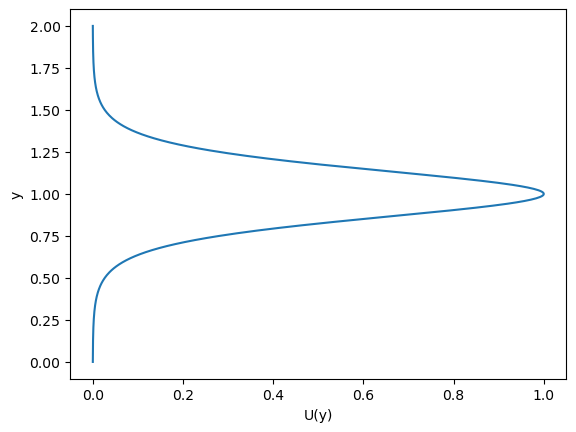

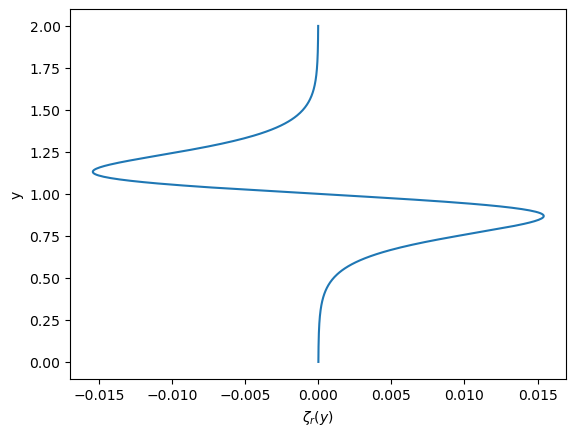

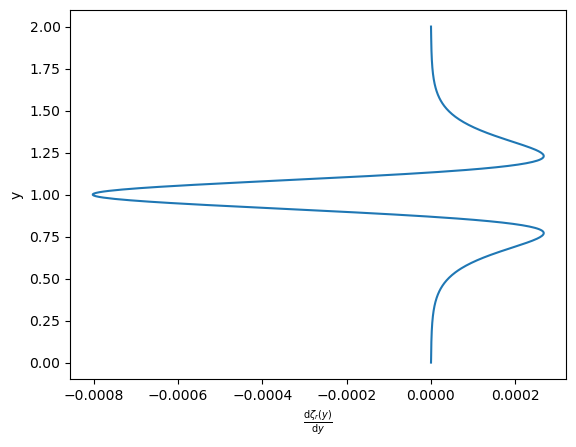

In [3]:
N_points = 500
x_lin = np.linspace(0.0, 2.0*np.pi,N_points, endpoint = False)
y_lin = np.linspace(0.0, 2.0, N_points)

def BickleyJet(y, gamma, U0=1.0, center = 0.0):
    "Jet de Bickley, de largeur gamma et de valeur max U0 (en y=0), centré en center"
    return U0*(np.cosh((y - center)/gamma))**(-2.0)

U = BickleyJet(y_lin, 0.2, center = 1.0)

vort = np.gradient(U)
grad_vort = np.gradient(vort)

fig = plt.figure()
plt.plot(U, y_lin)
plt.xlabel('U(y)')
plt.ylabel('y')

fig = plt.figure()
plt.plot(vort, y_lin)
plt.xlabel(f"$\zeta_r(y)$")
plt.ylabel('y')

fig = plt.figure()
plt.plot(grad_vort, y_lin)
plt.xlabel(r"$\frac{\mathrm{d}\zeta_r(y)}{\mathrm{d}y}$")
plt.ylabel('y')

## Test code ``Bickley_BT_Test.py``

In [4]:
import xarray as xr
import os
import IPython.display as ipd
repertoire_courant = os.getcwd()
print(repertoire_courant)

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\Test_Bickley_BT


In [22]:
#Permets de charger le contenu du fichier en mémoire.

exp_name = 'test_bickley_w_transport'

Ds_his = xr.load_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+'_his.nc')

Ds_diags = xr.load_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+"_diags.nc")

ipd.display(Ds_his)
ipd.display(Ds_diags)

<xarray.Dataset> Size: 50MB
Dimensions:    (t: 128, x: 128, y: 128)
Coordinates:
  * t          (t) float64 1kB 0.0 0.05027 0.1003 0.1503 ... 6.2 6.25 6.3 6.35
  * x          (x) float64 1kB 0.0 0.04909 0.09817 0.1473 ... 6.136 6.185 6.234
  * y          (y) float64 1kB 1.0 0.9997 0.9988 0.9972 ... -0.9988 -0.9997 -1.0
Data variables:
    psi        (t, x, y) float64 17MB 1.0 0.9997 0.9989 ... 0.0003332 0.0
    vorticity  (t, x, y) float64 17MB -0.8413 0.07863 0.0121 ... 0.1251 -0.09384
    PV         (t, x, y) float64 17MB 0.04552 0.07863 0.0121 ... 0.1251 -0.01609
Attributes: (12/29)
    title:                  test_bickley_w_transport_his.nc
    Nx:                     128
    Ny:                     128
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    1.0

<xarray.Dataset> Size: 6kB
Dimensions:           (t: 128)
Coordinates:
  * t                 (t) float64 1kB 0.0 0.05027 0.1003 ... 6.25 6.3 6.35
Data variables:
    kinetic_energy    (t) float64 1kB 3.917 3.917 3.917 ... 3.986 4.003 4.068
    potential_energy  (t) float64 1kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    total_energy      (t) float64 1kB 3.917 3.917 3.917 ... 3.986 4.003 4.068
    PV_total          (t) float64 1kB 0.01795 0.01795 ... 0.01518 0.006603
    enstrophy         (t) float64 1kB 67.06 67.06 67.06 ... 444.1 572.3 1.07e+03
Attributes: (12/29)
    title:                  test_bickley_w_transport_diags.nc
    Nx:                     128
    Ny:                     128
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    1.0

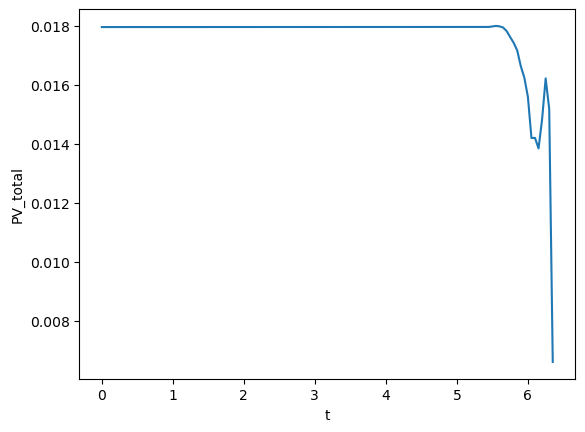

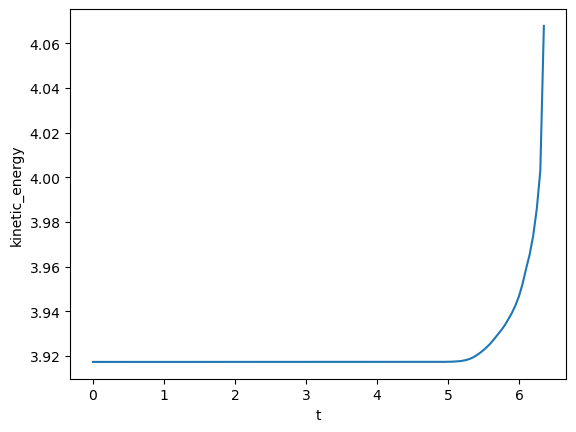

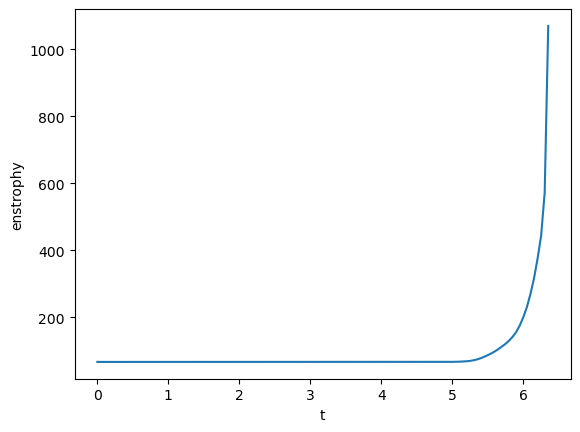

In [23]:
fig = plt.figure()
Ds_diags['PV_total'].plot()
plt.savefig('PV_total_exp_1.png')


fig = plt.figure()
Ds_diags['kinetic_energy'].plot()
plt.savefig('KE_total_exp_1.png')


fig = plt.figure()
Ds_diags['enstrophy'].plot()
plt.savefig('Enstr_total_exp_1.png')

<Figure size 640x480 with 0 Axes>

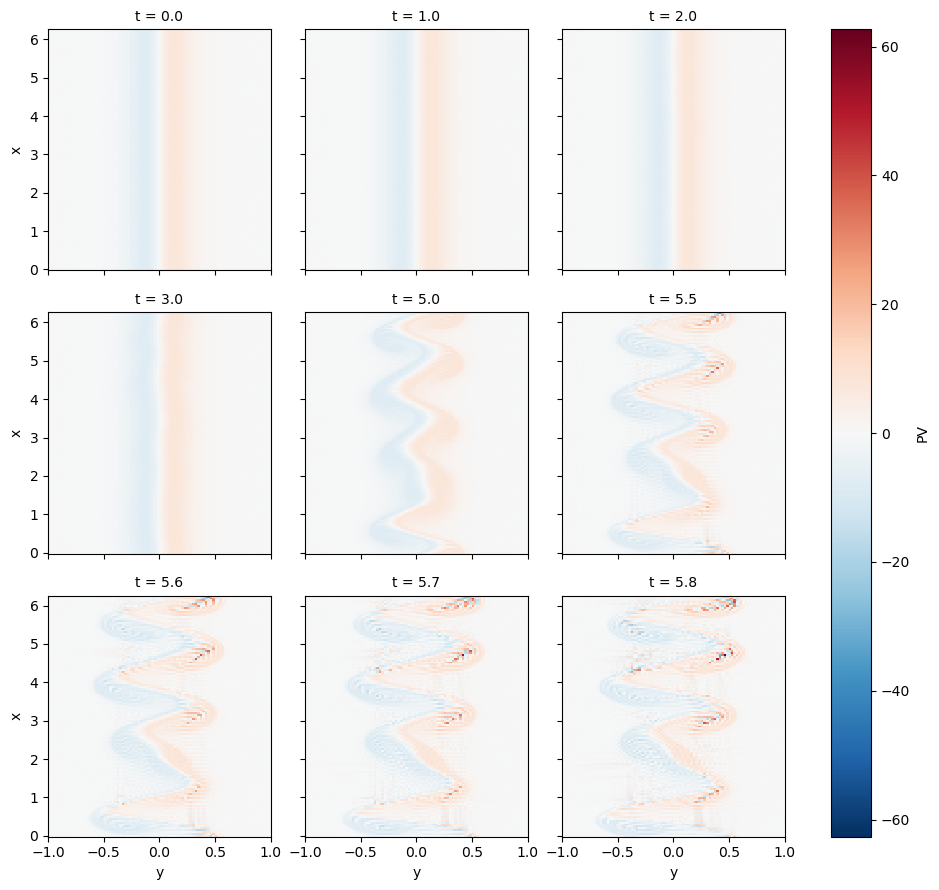

In [24]:
liste_t = [0.0, 1.0, 2.0, 3.0, 5.0, 5.5, 5.6, 5.7, 5.8]

fig = plt.figure()
Ds_his['PV'].sel(t=liste_t, method = 'nearest').plot.pcolormesh(col = 't', col_wrap = 3)
plt.savefig('vort_snap_exp_1.png')

In [8]:
import post_processing as ps

In [25]:
ps.animate(Ds_his['psi'], regular_grid = False)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=127, width=550)

In [28]:
ps.animate(Ds_his['vorticity'], regular_grid = False, clim = (-10.0, 10.0))

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=127, width=550)

In [31]:
ps.animate(Ds_his['PV'], regular_grid = False, clim = (-10.0, 10.0))

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=127, width=550)

In [11]:
np.random.normal(size = (10, 10))

array([[ 8.16972470e-01,  3.54020250e-01,  3.91906295e-02,
        -1.87418114e+00,  8.43453471e-01,  1.81252564e+00,
        -1.22215489e+00,  7.81245247e-01, -3.64565840e-01,
         8.25151297e-01],
       [-1.16035383e-01, -1.69479873e+00, -1.22684409e+00,
        -2.04049092e-01,  1.74236877e+00,  1.98456529e+00,
        -1.32372765e+00,  1.16740814e-04, -3.13588360e-01,
        -6.43365408e-01],
       [ 3.72947829e-01, -1.67801068e-01, -6.61501534e-01,
        -5.13914078e-01, -9.84873185e-01,  1.28434782e+00,
         4.41414595e-01, -3.64681052e-01, -3.87156725e-01,
        -1.42499251e+00],
       [ 4.65575912e-01,  1.46505325e-01, -7.27929202e-01,
         1.61809543e-01, -2.92330010e-01,  7.06072854e-01,
         4.43301912e-01,  8.65263760e-01,  1.76124653e+00,
         5.26089568e-01],
       [-1.24641541e+00, -1.38485322e+00,  8.78071990e-01,
        -3.48703445e-01,  1.76290564e-01,  2.43489427e-01,
         7.93751391e-01,  4.66803507e-02, -2.28790787e-01,
        -7.

In [12]:
diff_vort = Ds_his['vorticity'].sel(t=0.0, method = 'nearest') - Ds_his['vorticity'].sel(t=5.0, method = 'nearest')

In [13]:
diff_vort.values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [14]:
diff_PV = Ds_his['PV'].sel(t=0.0, method = 'nearest') - Ds_his['PV'].sel(t=5.0, method = 'nearest')

In [15]:
diff_PV

<xarray.DataArray 'PV' (x: 128, y: 128)> Size: 131kB
array([[-1.61051931,  0.03691752,  0.0600164 , ..., -0.06702824,
        -0.05447984,  0.66458065],
       [-0.64954759,  0.13207038,  0.11021379, ...,  0.00864447,
         0.01772538,  0.59194546],
       [ 1.5000468 , -0.00471135,  0.07380554, ..., -0.12350743,
        -0.05371166,  0.68939581],
       ...,
       [ 0.03350882,  0.08074696,  0.00504949, ...,  0.08304506,
        -0.01596493, -0.76671613],
       [-1.0810207 ,  0.25856539, -0.17932323, ..., -0.08007151,
         0.04679151, -0.08500949],
       [ 0.72005055, -0.12422436, -0.04701838, ..., -0.02336932,
         0.17529011,  0.62349431]])
Coordinates:
  * x        (x) float64 1kB 0.0 0.04909 0.09817 0.1473 ... 6.136 6.185 6.234
  * y        (y) float64 1kB 1.0 0.9997 0.9988 0.9972 ... -0.9988 -0.9997 -1.0

In [16]:
diff_psi = Ds_his['psi'].sel(t=0.0, method = 'nearest') - Ds_his['psi'].sel(t=5.0, method = 'nearest')
diff_psi.max()

<xarray.DataArray 'psi' ()> Size: 8B
array(0.)

## Comparaison avec la meme simulation faite avec fluid2d

In [33]:
exp_name = 'f2d_bickley_w_transport'

Ds_his_f2d = xr.open_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+'_his.nc')

Ds_diags_f2d = xr.open_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+"_diag.nc")

ipd.display(Ds_his_f2d)
ipd.display(Ds_diags_f2d)


fig = plt.figure()
Ds_diags_f2d['vorticity'].plot()



fig = plt.figure()
Ds_diags_f2d['ke'].plot()



fig = plt.figure()
Ds_diags_f2d['enstrophy'].plot()


<xarray.Dataset> Size: 59MB
Dimensions:    (y: 128, x: 128, t: 301)
Coordinates:
  * y          (y) float32 512B 0.007812 0.02344 0.03906 ... 1.961 1.977 1.992
  * x          (x) float32 512B 0.02454 0.07363 0.1227 ... 6.16 6.21 6.259
  * t          (t) float32 1kB 0.0 0.05 0.1 0.15 0.2 ... 14.85 14.9 14.95 15.0
Data variables:
    msk        (y, x) int32 66kB ...
    kt         (t) int32 1kB ...
    psi        (t, y, x) float32 20MB ...
    vorticity  (t, y, x) float32 20MB ...
    pv         (t, y, x) float32 20MB ...
Attributes: (12/61)
    modelname:              quasigeostrophic
    expname:                f2d_bickley_w_transport
    timestepping:           RK3_SSP
    order:                  5
    aparab:                 0.05
    flux_splitting_method:  parabolic
    ...                     ...
    plot_var:               vorticity
    beta:                   0.0
    Rd:                     1e+38
    nbproc:                 1
    whosetspsi:             pvanom
    qgoperator:             1

<xarray.Dataset> Size: 6kB
Dimensions:  (t: 301)
Coordinates:
  * t        (t) float32 1kB 0.0 0.05 0.1 0.15 0.2 ... 14.85 14.9 14.95 15.0
Data variables:
    kt       (t) int32 1kB ...
    ke       (t) float32 1kB ...
    pv       (t) float32 1kB ...
    pv2      (t) float32 1kB ...

KeyError: "No variable named 'vorticity'. Variables on the dataset include ['kt', 'ke', 'pv', 'pv2', 't']"

<Figure size 640x480 with 0 Axes>

In [34]:
ps.animate(Ds_his_f2d['pv'], regular_grid = True)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, width=550)

In [30]:
ps.animate(Ds_his_f2d['psi'], regular_grid = True)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, width=550)

In [ ]:
Ds_his_f2d['psi'].isel(y = 0).plot()

In [ ]:
(Ds_his_f2d['psi'] - 1.0).isel(y = -1).plot()

In [ ]:
(Ds_his_f2d['psi'] - 1.0).isel(y = -1).values

In [ ]:
(Ds_his_f2d['psi'] - 1.0).isel(y = 0).values